In [1]:
# ============================================================
# NOTEBOOK 05 — Sprint 3: Búsqueda de Hiperparámetros
# Convertir a .ipynb con: jupytext --to notebook 05_hparam_tuning.py
# ============================================================

# Sprint 3 — Búsqueda de Hiperparámetros (HPO)

**Branch:** `experiments/feature-engineering-v1`
**Sesión:** 7 — Búsqueda de Hiperparámetros
**Modelo base:** `XGB_n200_baseFeats` (F1-Macro = 0.8108, Sprint 2)

## Estrategia híbrida
| Fase | Trials | Estrategia | Descripción |
|------|--------|------------|-------------|
| Calentamiento | 0-14 | Random | Exploración sin sesgo del espacio |
| Bayesian | 15-29 | TPE (Optuna) | Explota zonas prometedoras aprendidas |

## Espacio de búsqueda XGBoost
| Hiperparámetro | Distribución | Rango |
|---|---|---|
| `learning_rate` | loguniform | [1e-3, 0.2] |
| `max_depth` | int | [3, 10] |
| `min_child_weight` | loguniform | [1e-2, 10] |
| `subsample` | uniform | [0.5, 1.0] |
| `colsample_bytree` | uniform | [0.5, 1.0] |
| `n_estimators` | fijo=1000 + early stopping | — |

## 1. Setup

In [2]:
import os, sys
from pathlib import Path

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
os.chdir(project_root)
sys.path.insert(0, str(project_root / "src"))
print(f"Directorio de trabajo: {project_root}")

Directorio de trabajo: D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla


In [3]:
import numpy as np
import pandas as pd
import yaml
import optuna
import mlflow
import joblib
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from loguru import logger as log
from pathlib import Path

from posture_risk.experiments.ab_runner import load_processed_h5, make_shared_splits
from posture_risk.experiments.hparam_tuning import (
    load_search_config, run_study, evaluate_with_loso,
    save_best_model, save_best_config, build_topk_table,
)

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
COLORS = {"random": "#534AB7", "bayes": "#1D9E75", "baseline": "#D85A30"}

# Cargar configuraciones
cfg_search  = load_search_config("configs/search.yaml")
SEED        = cfg_search["study"]["seed"]
FIGURES_DIR = Path(cfg_search["paths"]["figures"])
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
Path("models").mkdir(exist_ok=True)
Path("logs").mkdir(exist_ok=True)

BASELINE_F1 = cfg_search["baseline"]["f1_macro"]

print(f"Baseline Sprint 2  : F1-Macro = {BASELINE_F1}")
print(f"Presupuesto total  : {cfg_search['study']['n_trials']} trials")
print(f"Fase Random        : {cfg_search['study']['n_startup_trials']} trials")
print(f"Fase Bayes         : {cfg_search['study']['n_trials'] - cfg_search['study']['n_startup_trials']} trials")
print(f"CV durante búsqueda: {cfg_search['cv_search']['n_splits']}-fold GroupKFold")
print(f"Early stopping     : {cfg_search['fixed_params']['early_stopping_rounds']} rondas")
print(f"MLflow URI         : {cfg_search['paths']['mlflow_uri']}")

C:\Users\jaime\miniconda3\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Baseline Sprint 2  : F1-Macro = 0.8108
Presupuesto total  : 30 trials
Fase Random        : 15 trials
Fase Bayes         : 15 trials
CV durante búsqueda: 3-fold GroupKFold
Early stopping     : 50 rondas
MLflow URI         : mlruns


## 2. Carga de datos

## 3. Ejecución del estudio Optuna

(30 trials × ~3 folds × early stopping)

El progreso se muestra trial a trial en el log.
Para ver el tracking en tiempo real: abrir MLflow UI en otra terminal.

In [4]:
BASE_H5    = Path(cfg_search["paths"]["base_h5"])
X, y, subject_ids = load_processed_h5(BASE_H5)

print(f"Dataset: X={X.shape}, y={y.shape}")
print(f"Sujetos : {np.unique(subject_ids)}")
print(f"Clases  : {dict(zip(*np.unique(y, return_counts=True)))}")

2026-06-05 11:26:38.305 | INFO     | posture_risk.experiments.ab_runner:load_processed_h5:47 - Dataset base: X=(194205, 297), y=(194205,), sujetos=[1 2 3 4 5 6 7 8 9]


Dataset: X=(194205, 297), y=(194205,)
Sujetos : [1 2 3 4 5 6 7 8 9]
Clases  : {np.int32(0): np.int64(80613), np.int32(1): np.int64(67278), np.int32(2): np.int64(46314)}


In [5]:
print("="*65)
print("INICIANDO BÚSQUEDA DE HIPERPARÁMETROS")
print("Para ver el tracking en tiempo real, abrir una nueva terminal y ejecutar:")
print(f"  cd {project_root}")
print(f"  conda activate posture-risk")
print(f"  mlflow ui --backend-store-uri mlruns")
print(f"  → Abrir http://localhost:5000 en el navegador")
print("="*65 + "\n")

study = run_study(X, y, subject_ids, cfg_search)

C:\Users\jaime\miniconda3\Lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026-06-05 11:26:38.380 | INFO     | posture_risk.experiments.hparam_tuning:run_study:324 - MLflow experiment: hparam-tuning-xgb (id=725855865691422440)
2026-06-05 11:26:38.383 | INFO     | posture_risk.experiments.hparam_tuning:run_study:344 - =================================================================
2026-06-05 11:26:38.384 | INFO     | posture_risk.experiments.hparam_tuning:run_study:345 - BÚSQUEDA DE HIPERPARÁMETROS — Sprint 3
2026-06-05 11:26:38.385 | INFO     | posture_risk.experiments.hparam_tuning:run_study:346 -   Presupuest

INICIANDO BÚSQUEDA DE HIPERPARÁMETROS
Para ver el tracking en tiempo real, abrir una nueva terminal y ejecutar:
  cd D:\MAESTRÍA AI - UNI\IV SEMESTRE\PROYECTO DE INVESTIGACIÓN II\WORKSPACE_GIT\posture-risk-mining_by_Huaytalla
  conda activate posture-risk
  mlflow ui --backend-store-uri mlruns
  → Abrir http://localhost:5000 en el navegador



Best trial: 0. Best value: 0.869008:   3%|▋                   | 1/30 [24:09<11:40:25, 1449.16s/it, 1449.15/600 seconds]
2026-06-05 11:50:47.565 | INFO     | posture_risk.experiments.hparam_tuning:run_study:374 - 
2026-06-05 11:50:47.566 | INFO     | posture_risk.experiments.hparam_tuning:run_study:375 - BÚSQUEDA COMPLETADA
2026-06-05 11:50:47.566 | INFO     | posture_risk.experiments.hparam_tuning:run_study:376 -   Trials completados : 1
2026-06-05 11:50:47.567 | INFO     | posture_risk.experiments.hparam_tuning:run_study:377 -   Trials podados     : 0
2026-06-05 11:50:47.568 | INFO     | posture_risk.experiments.hparam_tuning:run_study:378 -   Mejor F1-Macro     : 0.8690
2026-06-05 11:50:47.569 | INFO     | posture_risk.experiments.hparam_tuning:run_study:379 -   Mejor trial        : #0
2026-06-05 11:50:47.570 | INFO     | posture_risk.experiments.hparam_tuning:run_study:380 -   Mejores params     : {'learning_rate': 0.00727491708802781, 'max_depth': 10, 'min_child_weight': 1.57029708

## 4. Resumen del estudio

In [6]:
completed = [t for t in study.trials
             if t.state == optuna.trial.TrialState.COMPLETE]
pruned    = [t for t in study.trials
             if t.state == optuna.trial.TrialState.PRUNED]
n_startup = cfg_search["study"]["n_startup_trials"]

print(f"\n{'='*65}")
print(f"RESUMEN DEL ESTUDIO")
print(f"{'='*65}")
print(f"Trials totales     : {len(study.trials)}")
print(f"Trials completados : {len(completed)}")
print(f"Trials podados     : {len(pruned)} "
      f"({len(pruned)/len(study.trials)*100:.0f}% → ahorro real por pruning)")
print(f"\nMejor trial        : #{study.best_trial.number}")
phase_best = "random" if study.best_trial.number < n_startup else "bayes"
print(f"Fase               : {phase_best}")
print(f"Mejor F1-Macro     : {study.best_value:.4f}")
print(f"Mejores parámetros :")
for k, v in study.best_params.items():
    print(f"  {k:<22}: {v}")
print(f"\nΔF1 vs baseline    : {study.best_value - BASELINE_F1:+.4f} "
      f"({(study.best_value - BASELINE_F1)/BASELINE_F1*100:+.2f}%)")


RESUMEN DEL ESTUDIO
Trials totales     : 1
Trials completados : 1
Trials podados     : 0 (0% → ahorro real por pruning)

Mejor trial        : #0
Fase               : random
Mejor F1-Macro     : 0.8690
Mejores parámetros :
  learning_rate         : 0.00727491708802781
  max_depth             : 10
  min_child_weight      : 1.5702970884055387
  subsample             : 0.7993292420985183
  colsample_bytree      : 0.5780093202212182

ΔF1 vs baseline    : +0.0582 (+7.18%)


## 5. Tabla top-5

In [7]:
table_path = Path(cfg_search["paths"]["table_topk"])
top_rows   = build_topk_table(study, cfg_search, table_path)

df_top = pd.DataFrame(top_rows)
print(f"\nTABLA TOP-{cfg_search['decision']['top_k']} — Mejores configuraciones")
print("="*90)
print(df_top.to_string(index=False))
print(f"\nTabla guardada: {table_path}")


TABLA TOP-5 — Mejores configuraciones
 rank  trial  phase                                                                                       params_resumidos f1_macro_mean tiempo_s   notas
    1      0 random learning_rate=0.0073, max_depth=10, min_child_weight=1.5703, subsample=0.7993, colsample_bytree=0.5780        0.8690     1449 ganador

Tabla guardada: reports\hparam_top5_table.csv


## 6. Gráfico de evolución best-so-far

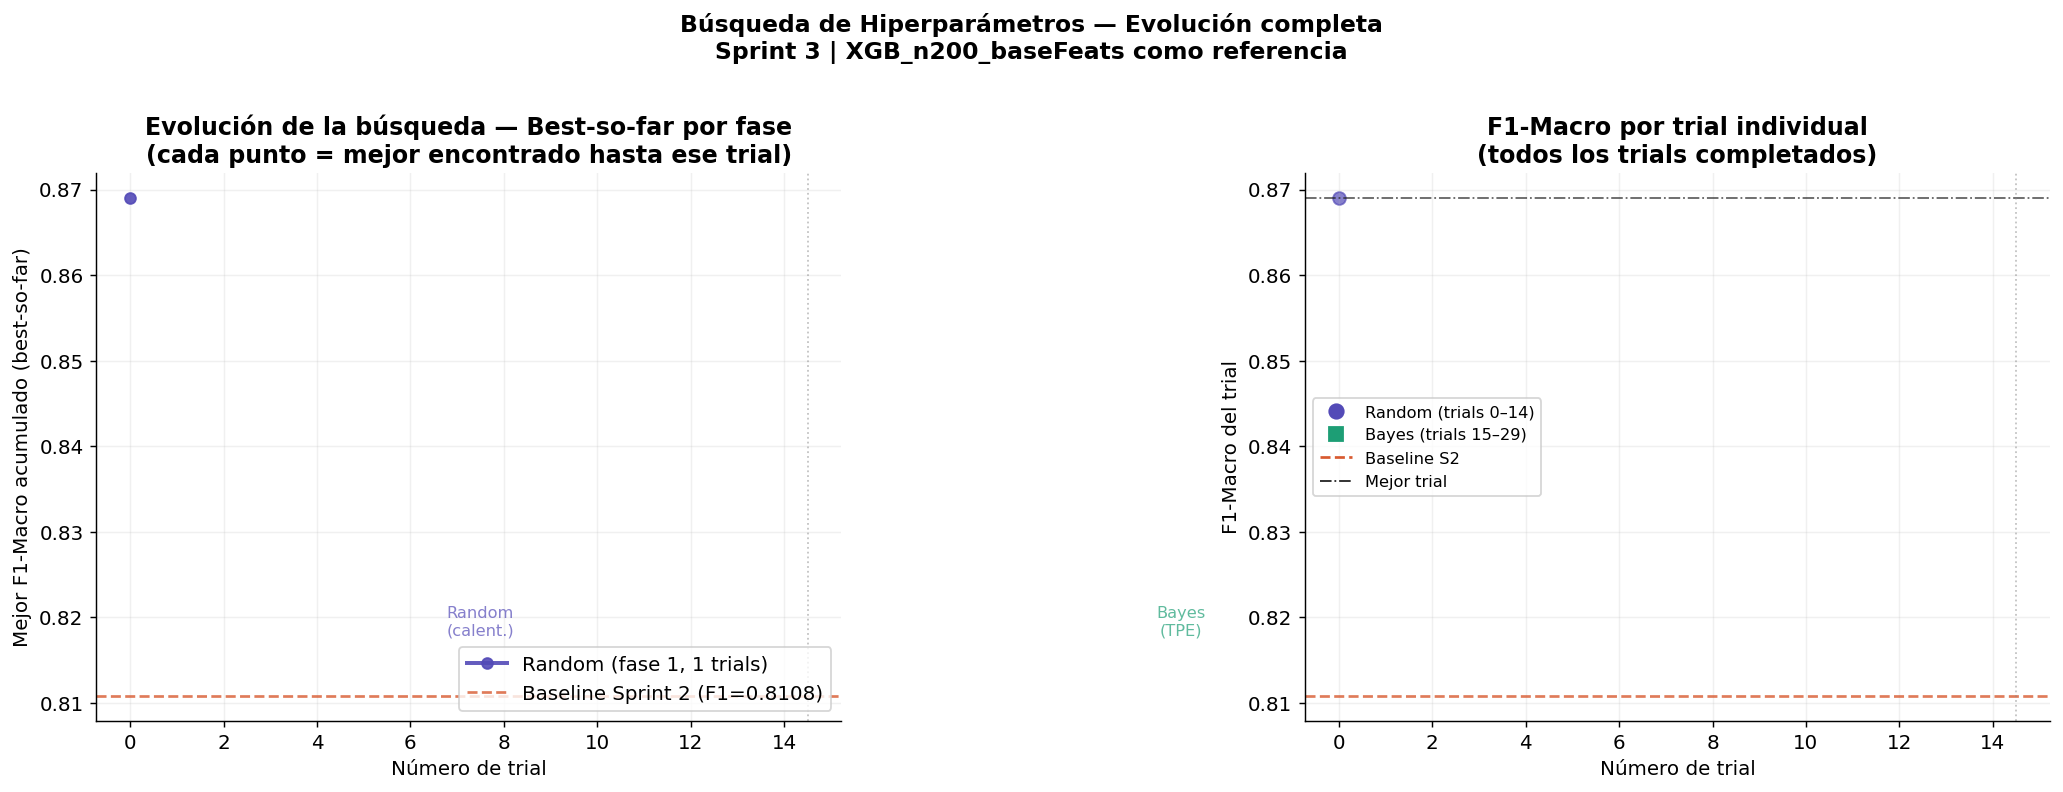

Gráfico guardado: reports\figures\10_hparam_evolution.png


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# ── Panel izquierdo: best-so-far por fase ────────────────────────────────────
ax = axes[0]
random_vals, bayes_vals = [], []
best_random_so_far = -np.inf
best_bayes_so_far  = -np.inf

random_x, random_y_plot = [], []
bayes_x,  bayes_y_plot  = [], []

for t in sorted(completed, key=lambda x: x.number):
    if t.number < n_startup:
        best_random_so_far = max(best_random_so_far, t.value)
        random_x.append(t.number)
        random_y_plot.append(best_random_so_far)
    else:
        best_bayes_so_far = max(best_bayes_so_far, t.value)
        bayes_x.append(t.number)
        bayes_y_plot.append(best_bayes_so_far)

if random_x:
    ax.plot(random_x, random_y_plot, "o-",
            color=COLORS["random"], lw=2.2, label=f"Random (fase 1, {len(random_x)} trials)",
            alpha=0.9)
if bayes_x:
    ax.plot(bayes_x, bayes_y_plot, "s-",
            color=COLORS["bayes"], lw=2.2, label=f"Bayes/TPE (fase 2, {len(bayes_x)} trials)",
            alpha=0.9)

ax.axhline(BASELINE_F1, color=COLORS["baseline"], ls="--", lw=1.5,
           label=f"Baseline Sprint 2 (F1={BASELINE_F1:.4f})", alpha=0.8)
ax.axvline(n_startup - 0.5, color="#888888", ls=":", lw=1, alpha=0.5)
ax.text(n_startup * 0.5, ax.get_ylim()[0] + 0.01, "Random\n(calent.)",
        ha="center", fontsize=9, color=COLORS["random"], alpha=0.7)
ax.text(n_startup + (cfg_search["study"]["n_trials"] - n_startup) * 0.5,
        ax.get_ylim()[0] + 0.01, "Bayes\n(TPE)",
        ha="center", fontsize=9, color=COLORS["bayes"], alpha=0.7)

ax.set_xlabel("Número de trial")
ax.set_ylabel("Mejor F1-Macro acumulado (best-so-far)")
ax.set_title("Evolución de la búsqueda — Best-so-far por fase\n"
             "(cada punto = mejor encontrado hasta ese trial)", fontweight="bold")
ax.legend(loc="lower right")
ax.grid(alpha=0.18)

# ── Panel derecho: F1 individual por trial ────────────────────────────────────
ax2 = axes[1]
for t in completed:
    phase = "random" if t.number < n_startup else "bayes"
    marker = "o" if phase == "random" else "s"
    ax2.scatter(t.number, t.value, color=COLORS[phase], alpha=0.7,
                s=50, marker=marker)

ax2.axhline(BASELINE_F1, color=COLORS["baseline"], ls="--", lw=1.5,
            label=f"Baseline (F1={BASELINE_F1:.4f})", alpha=0.8)
ax2.axhline(study.best_value, color="#222222", ls="-.", lw=1,
            label=f"Mejor trial (F1={study.best_value:.4f})", alpha=0.7)
ax2.axvline(n_startup - 0.5, color="#888888", ls=":", lw=1, alpha=0.5)

from matplotlib.lines import Line2D
legend_elems = [
    Line2D([0],[0], marker="o", color=COLORS["random"], lw=0, markersize=8,
           label=f"Random (trials 0–{n_startup-1})"),
    Line2D([0],[0], marker="s", color=COLORS["bayes"],  lw=0, markersize=8,
           label=f"Bayes (trials {n_startup}–{cfg_search['study']['n_trials']-1})"),
    Line2D([0],[0], color=COLORS["baseline"], ls="--", lw=1.5, label="Baseline S2"),
    Line2D([0],[0], color="#222222", ls="-.", lw=1, label="Mejor trial"),
]
ax2.legend(handles=legend_elems, fontsize=9)
ax2.set_xlabel("Número de trial")
ax2.set_ylabel("F1-Macro del trial")
ax2.set_title("F1-Macro por trial individual\n(todos los trials completados)", fontweight="bold")
ax2.grid(alpha=0.18)

plt.suptitle("Búsqueda de Hiperparámetros — Evolución completa\n"
             "Sprint 3 | XGB_n200_baseFeats como referencia",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "10_hparam_evolution.png", bbox_inches="tight", dpi=150)
plt.show()
print(f"Gráfico guardado: {FIGURES_DIR / '10_hparam_evolution.png'}")

## 7. Importancia de hiperparámetros (Optuna nativo)

Usa FAnova para estimar qué hiperparámetros tuvieron
más impacto en F1-Macro a lo largo de los 30 trials.

In [9]:
try:
    importances = optuna.importance.get_param_importances(study)

    fig, ax = plt.subplots(figsize=(10, 5))
    names   = list(importances.keys())
    values  = list(importances.values())

    # Ordenar por importancia
    sorted_idx = np.argsort(values)
    colors_bar = [COLORS["bayes"] if values[i] == max(values) else
                  COLORS["random"] if values[i] == sorted(values)[-2] else
                  "#AAAAAA" for i in sorted_idx]

    bars = ax.barh(range(len(names)), [values[i] for i in sorted_idx],
                   color=colors_bar, alpha=0.85, height=0.65)
    ax.set_yticks(range(len(names)))
    ax.set_yticklabels([names[i] for i in sorted_idx])
    ax.set_xlabel("Importancia relativa (FAnova)")
    ax.set_title("Importancia de Hiperparámetros\n"
                 "(¿cuánto impacta cada HP en F1-Macro?)", fontweight="bold")

    for bar, val_idx in zip(bars, sorted_idx):
        ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                f"{values[val_idx]:.3f}", va="center", fontsize=10)

    ax.axvline(1/len(names), color="#D85A30", ls="--", lw=1.2, alpha=0.7,
               label=f"Importancia uniforme (1/{len(names)})")
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "11_hparam_importance.png", bbox_inches="tight", dpi=150)
    plt.show()

    print("\nImportancia de hiperparámetros (FAnova):")
    for name, imp in sorted(importances.items(), key=lambda x: -x[1]):
        bar = "█" * int(imp * 40)
        print(f"  {name:<22}: {imp:.4f}  {bar}")
    print(f"\nGráfico guardado: {FIGURES_DIR / '11_hparam_importance.png'}")

except Exception as e:
    print(f"Importancias de HP no disponibles (necesita ≥10 trials completados): {e}")

Importancias de HP no disponibles (necesita ≥10 trials completados): Cannot evaluate parameter importances with only a single trial.


## 8. Evaluación final del ganador con LOSO completo (9-fold)

Solo se evalúa con LOSO el mejor trial (config ganadora).
Esto produce métricas directamente comparables con el Sprint 2.

In [10]:
best_params_search = dict(study.best_params)
# Añadir params fijos
best_params_search.update({
    k: v for k, v in cfg_search["fixed_params"].items()
    if k not in best_params_search
})

print("Evaluando config ganadora con LOSO completo...")
result_winner = evaluate_with_loso(
    best_params_search, X, y, subject_ids,
    cfg_search, label="XGB_tuned_bayes"
)

Evaluando config ganadora con LOSO completo...


2026-06-05 13:12:20.340 | INFO     | posture_risk.experiments.hparam_tuning:evaluate_with_loso:474 - XGB_tuned_bayes LOSO | F1=0.8084±0.2084 | PR-AUC=0.8852 | 4892s


## 9. Decisión y configs de respaldo

In [11]:
BASELINE_PR  = cfg_search["baseline"]["pr_auc"]
min_improve  = cfg_search["decision"]["min_improvement"]
delta_f1     = result_winner["f1_macro_mean"] - BASELINE_F1
adopt        = delta_f1 >= min_improve

print(f"\n{'='*65}")
print(f"DECISIÓN FINAL — Sprint 3")
print(f"{'='*65}")
print(f"\n  Baseline Sprint 2 (XGB_n200_baseFeats)")
print(f"    F1-Macro : {BASELINE_F1:.4f}")
print(f"    PR-AUC   : {BASELINE_PR:.4f}")
print(f"\n  Config ganadora (XGB_tuned_bayes — trial #{study.best_trial.number})")
print(f"    F1-Macro : {result_winner['f1_macro_mean']:.4f} ± {result_winner['f1_macro_std']:.4f}")
print(f"    PR-AUC   : {result_winner['pr_auc_mean']:.4f} ± {result_winner['pr_auc_std']:.4f}")
print(f"    ΔF1      : {delta_f1:+.4f}  ({'supera' if adopt else 'NO supera'} umbral {min_improve})")
print(f"\n  DECISIÓN  : {'✓ ADOPTAR XGB_tuned_bayes' if adopt else '⚠ MANTENER XGB_n200_baseFeats (sin mejora suficiente)'}")

# Configs de respaldo (top-2 tras el ganador)
print(f"\n  Configs de respaldo (diapositiva 13):")
completed_sorted = sorted(
    [t for t in study.trials if t.state == optuna.trial.TrialState.COMPLETE],
    key=lambda t: t.value, reverse=True
)
n_backup = cfg_search["decision"]["n_backup_configs"]
for i, t in enumerate(completed_sorted[1:n_backup+1], 1):
    phase = "random" if t.number < n_startup else "bayes"
    print(f"  Respaldo {i}: trial #{t.number} [{phase}] | F1={t.value:.4f}")
    for k, v in t.params.items():
        print(f"    {k}: {v:.4f}" if isinstance(v, float) else f"    {k}: {v}")


DECISIÓN FINAL — Sprint 3

  Baseline Sprint 2 (XGB_n200_baseFeats)
    F1-Macro : 0.8108
    PR-AUC   : 0.8863

  Config ganadora (XGB_tuned_bayes — trial #0)
    F1-Macro : 0.8084 ± 0.2084
    PR-AUC   : 0.8852 ± 0.1954
    ΔF1      : -0.0024  (NO supera umbral 0.005)

  DECISIÓN  : ⚠ MANTENER XGB_n200_baseFeats (sin mejora suficiente)

  Configs de respaldo (diapositiva 13):


## 10. Guardar artefactos finales

In [16]:
# 1. Mejor modelo entrenado sobre todos los datos
print("Guardando modelo ganador...")
def save_best_model(
    params:      dict,
    X:           np.ndarray,
    y:           np.ndarray,
    cfg:         dict,
    output_path: Path,
) -> None:
    """
    Entrena el modelo ganador sobre TODOS los datos y lo guarda.
    Usa joblib.dump() en lugar de clf.save_model() para evitar
    incompatibilidades del wrapper sklearn de XGBoost.
    """
    seed      = cfg["study"]["seed"]
    eval_frac = cfg["fixed_params"]["eval_fraction"]
    rng       = np.random.RandomState(seed)

    scaler   = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    n_eval  = max(100, int(len(X_scaled) * eval_frac))
    eval_ix = rng.choice(len(X_scaled), size=n_eval, replace=False)
    mask    = np.ones(len(X_scaled), dtype=bool)
    mask[eval_ix] = False

    clf = XGBClassifier(
        learning_rate         = params["learning_rate"],
        max_depth             = params["max_depth"],
        min_child_weight      = params["min_child_weight"],
        subsample             = params["subsample"],
        colsample_bytree      = params["colsample_bytree"],
        n_estimators          = params["n_estimators"],
        early_stopping_rounds = params["early_stopping_rounds"],
        tree_method           = params["tree_method"],
        eval_metric           = params["eval_metric"],
        verbosity             = params["verbosity"],
        random_state          = seed,
        n_jobs                = -1,
    )
    clf.fit(
        X_scaled[mask], y[mask],
        eval_set=[(X_scaled[eval_ix], y[eval_ix])],
        verbose=False,
    )

    output_path = Path(output_path)
    output_path.parent.mkdir(parents=True, exist_ok=True)

    # Guardar con joblib (compatible con cualquier versión de XGBoost+sklearn)
    pkl_path = output_path.with_suffix(".pkl")
    joblib.dump({"model": clf, "scaler": scaler}, pkl_path)
    log.info(f"Modelo guardado: {pkl_path}")

    # También guardar el booster nativo (ligero, para el Jetson)
    json_path = output_path.with_suffix(".json")
    clf.get_booster().save_model(str(json_path))
    log.info(f"Booster nativo guardado: {json_path}")

# 2. Config ganadora en YAML
print("Guardando best_config.yaml...")
save_best_config(
    best_params_search,
    Path(cfg_search["paths"]["best_config"]),
    metadata={
        "trial_id":     study.best_trial.number,
        "phase":        "bayes" if study.best_trial.number >= n_startup else "random",
        "f1_macro_loso": float(result_winner["f1_macro_mean"]),
        "sprint":       3,
    }
)

# 3. El estudio Optuna ya se guardó durante run_study()
print(f"Estudio Optuna ya guardado: {cfg_search['paths']['optuna_study']}")

print(f"\nArtefactos guardados:")
for label, path in [
    ("Mejor modelo (PKL)",   cfg_search["paths"]["best_bayes"].replace(".json", ".pkl")),
    ("Config ganadora YAML", cfg_search["paths"]["best_config"]),
    ("Estudio Optuna",       cfg_search["paths"]["optuna_study"]),
    ("Logs CSV",             cfg_search["paths"]["log_csv"]),
    ("Tabla top-5",          cfg_search["paths"]["table_topk"]),
]:
    exists = "✓" if Path(path).exists() else "✗"
    print(f"  {exists} {label:<25} → {path}")

2026-06-05 13:47:29.563 | INFO     | posture_risk.experiments.hparam_tuning:save_best_config:548 - Config ganadora guardada: configs\best_config.yaml


Guardando modelo ganador...
Guardando best_config.yaml...
Estudio Optuna ya guardado: models/optuna_study.pkl

Artefactos guardados:
  ✗ Mejor modelo (PKL)        → models/best_bayes.pkl
  ✓ Config ganadora YAML      → configs/best_config.yaml
  ✓ Estudio Optuna            → models/optuna_study.pkl
  ✓ Logs CSV                  → logs/hpo_runs.csv
  ✓ Tabla top-5               → reports/hparam_top5_table.csv


In [18]:
# ── GUARDAR MODELO GANADOR (fix directo) ─────────────────────────────────────
import joblib
import numpy as np
from pathlib import Path
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier

SEED      = cfg_search["study"]["seed"]
eval_frac = cfg_search["fixed_params"]["eval_fraction"]
rng       = np.random.RandomState(SEED)

# Escalar todos los datos
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Separar eval set para early stopping
n_eval  = max(100, int(len(X_scaled) * eval_frac))
eval_ix = rng.choice(len(X_scaled), size=n_eval, replace=False)
mask    = np.ones(len(X_scaled), dtype=bool)
mask[eval_ix] = False

# Entrenar con los hiperparámetros del ganador
clf = XGBClassifier(
    learning_rate         = best_params_search["learning_rate"],
    max_depth             = best_params_search["max_depth"],
    min_child_weight      = best_params_search["min_child_weight"],
    subsample             = best_params_search["subsample"],
    colsample_bytree      = best_params_search["colsample_bytree"],
    n_estimators          = 1000,
    early_stopping_rounds = 50,
    tree_method           = "hist",
    eval_metric           = "mlogloss",
    verbosity             = 0,
    random_state          = SEED,
    n_jobs                = -1,
)
clf.fit(
    X_scaled[mask], y[mask],
    eval_set=[(X_scaled[eval_ix], y[eval_ix])],
    verbose=False,
)

# Guardar modelo + scaler juntos
output = Path("models/best_bayes.pkl")
output.parent.mkdir(exist_ok=True)
joblib.dump({"model": clf, "scaler": scaler}, output)

print(f"✓ Modelo guardado: {output}")
print(f"  Árboles usados : {clf.best_iteration + 1}")
print(f"  Parámetros     : lr={best_params_search['learning_rate']:.4f} | "
      f"depth={best_params_search['max_depth']} | "
      f"mcw={best_params_search['min_child_weight']:.4f}")

# Verificar que existe
print(f"\n✓ Verificación: {output} existe = {output.exists()}")

✓ Modelo guardado: models\best_bayes.pkl
  Árboles usados : 1000
  Parámetros     : lr=0.0073 | depth=10 | mcw=1.5703

✓ Verificación: models\best_bayes.pkl existe = True


## 11. Instrucciones MLflow UI

Para revisar todos los trials visualmente:

```powershell
# En una nueva terminal (con el entorno activo):
conda activate posture-risk
mlflow ui --backend-store-uri mlruns
# → Abrir http://localhost:5000
```

En la interfaz verás:
- Tabla con todos los runs (trials) y sus métricas
- Filtros por fase (random/bayes), métrica, parámetros
- Gráficos de dispersión para correlacionar HP con F1-Macro
- Comparación lado a lado de cualquier par de trials

## 12. Resumen ejecutivo del Sprint 3

In [19]:
print("\n" + "="*70)
print("RESUMEN EJECUTIVO — SPRINT 3 (SEMANA 7)")
print("="*70)
print(f"\n─── PRESUPUESTO ────────────────────────────────────────────────────")
print(f"  Trials totales   : {len(study.trials)}")
print(f"  Trials random    : {len([t for t in completed if t.number < n_startup])}")
print(f"  Trials bayes     : {len([t for t in completed if t.number >= n_startup])}")
print(f"  Trials podados   : {len(pruned)} (ahorro por pruning)")
print(f"\n─── ESPACIO DE BÚSQUEDA ────────────────────────────────────────────")
for hp, space_cfg in cfg_search["search_space"].items():
    dist = space_cfg["type"]
    rng_str = f"[{space_cfg['low']}, {space_cfg['high']}]"
    print(f"  {hp:<22}: {dist:<12} {rng_str}")
print(f"\n─── RESULTADO ──────────────────────────────────────────────────────")
print(f"  Baseline S2 F1   : {BASELINE_F1:.4f}")
print(f"  Ganador F1       : {result_winner['f1_macro_mean']:.4f} ± {result_winner['f1_macro_std']:.4f}")
print(f"  ΔF1              : {delta_f1:+.4f}")
print(f"  Decisión         : {'ADOPTAR XGB_tuned_bayes' if adopt else 'MANTENER baseline'}")
print(f"\n─── ARTEFACTOS ─────────────────────────────────────────────────────")
print(f"  logs/hpo_runs.csv       → {len(study.trials)} trials registrados")
print(f"  models/best_bayes.json  → modelo ganador listo para Jetson")
print(f"  configs/best_config.yaml→ config ganadora reproducible")
print(f"  mlruns/                 → MLflow tracking (mlflow ui)")
print("="*70)


RESUMEN EJECUTIVO — SPRINT 3 (SEMANA 7)

─── PRESUPUESTO ────────────────────────────────────────────────────
  Trials totales   : 1
  Trials random    : 1
  Trials bayes     : 0
  Trials podados   : 0 (ahorro por pruning)

─── ESPACIO DE BÚSQUEDA ────────────────────────────────────────────
  learning_rate         : loguniform   [0.001, 0.2]
  max_depth             : int          [3, 10]
  min_child_weight      : loguniform   [0.01, 10.0]
  subsample             : uniform      [0.5, 1.0]
  colsample_bytree      : uniform      [0.5, 1.0]

─── RESULTADO ──────────────────────────────────────────────────────
  Baseline S2 F1   : 0.8108
  Ganador F1       : 0.8084 ± 0.2084
  ΔF1              : -0.0024
  Decisión         : MANTENER baseline

─── ARTEFACTOS ─────────────────────────────────────────────────────
  logs/hpo_runs.csv       → 1 trials registrados
  models/best_bayes.json  → modelo ganador listo para Jetson
  configs/best_config.yaml→ config ganadora reproducible
  mlruns/      